# Bitcoin Market Sentiment vs Trader Performance Analysis

## Internship Assignment

### Candidate:
Priyanka

### Company:
Primetrade.ai

### Objective

This project investigates the relationship between Bitcoin market sentiment
(Fear and Greed Index) and trader performance using historical Hyperliquid
trading data.

The goal is to discover trading patterns, evaluate trader behavior under
different market sentiments, and generate actionable trading insights.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 20)

# Visualization Style
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


# Load the Datasets

In this section, we load the historical trading dataset and the
Bitcoin Fear & Greed Index dataset.

In [2]:
historical_df = pd.read_csv(r"C:\Users\PRIYANKA\Downloads\historical_data.csv")

sentiment_df = pd.read_csv(r"C:\Users\PRIYANKA\Downloads\fear_greed_index (1).csv")

print("Historical Dataset Shape :", historical_df.shape)
print("Sentiment Dataset Shape :", sentiment_df.shape)

Historical Dataset Shape : (211224, 16)
Sentiment Dataset Shape : (2644, 4)


# Preview Historical Dataset

Understanding the structure of the trading dataset.

In [3]:
historical_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [4]:
sentiment_df.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


# Dataset Information

Checking column names, data types, and missing values.

In [5]:
sentiment_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [6]:
print("Historical Dataset")

historical_df.isnull().sum()

Historical Dataset


Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [7]:
print("Sentiment Dataset")

sentiment_df.isnull().sum()

Sentiment Dataset


timestamp         0
value             0
classification    0
date              0
dtype: int64

# Check Duplicate Records

In [8]:
print("Historical Duplicates :", historical_df.duplicated().sum())

print("Sentiment Duplicates :", sentiment_df.duplicated().sum())

Historical Duplicates : 0
Sentiment Duplicates : 0


# Statistical Summary

In [9]:
historical_df.describe(include="all")

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
count,211224,211224,211224.000000,2.112240e+05,2.112240e+05,211224,211224,2.112240e+05,211224,211224.000000,211224,2.112240e+05,211224,211224.000000,2.112240e+05,2.112240e+05
unique,32,246,NaN,NaN,NaN,2,27977,NaN,12,NaN,101184,NaN,2,NaN,NaN,NaN
top,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,HYPE,NaN,NaN,NaN,SELL,14-02-2025 00:31,NaN,Open Long,NaN,0x00000000000000000000000000000000000000000000...,NaN,True,NaN,NaN,NaN
freq,40184,68005,NaN,NaN,NaN,108528,441,NaN,49895,NaN,9032,NaN,128403,NaN,NaN,NaN
mean,NaN,NaN,11414.723350,4.623365e+03,5.639451e+03,NaN,NaN,-2.994625e+04,NaN,48.749001,NaN,6.965388e+10,NaN,1.163967,5.628549e+14,1.737744e+12
std,NaN,NaN,29447.654868,1.042729e+05,3.657514e+04,NaN,NaN,6.738074e+05,NaN,919.164828,NaN,1.835753e+10,NaN,6.758854,3.257565e+14,8.689920e+09
min,NaN,NaN,0.000005,8.740000e-07,0.000000e+00,NaN,NaN,-1.433463e+07,NaN,-117990.104100,NaN,1.732711e+08,NaN,-1.175712,0.000000e+00,1.680000e+12
25%,NaN,NaN,4.854700,2.940000e+00,1.937900e+02,NaN,NaN,-3.762311e+02,NaN,0.000000,NaN,5.983853e+10,NaN,0.016121,2.810000e+14,1.740000e+12
50%,NaN,NaN,18.280000,3.200000e+01,5.970450e+02,NaN,NaN,8.472793e+01,NaN,0.000000,NaN,7.442939e+10,NaN,0.089578,5.620000e+14,1.740000e+12
75%,NaN,NaN,101.580000,1.879025e+02,2.058960e+03,NaN,NaN,9.337278e+03,NaN,5.792797,NaN,8.335543e+10,NaN,0.393811,8.460000e+14,1.740000e+12


In [18]:
historical_df.isnull().sum().sort_values(ascending=False)

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
Date                0
dtype: int64

In [19]:
sentiment_df.isnull().sum().sort_values(ascending=False)

timestamp         0
value             0
classification    0
date              0
dtype: int64

# Convert Date Columns

Preparing the datasets for merging.

In [11]:
historical_df["Timestamp"] = pd.to_datetime(historical_df["Timestamp"])

historical_df["Date"] = historical_df["Timestamp"].dt.date

In [37]:
# Convert Timestamp IST to datetime
historical_df["Timestamp IST"] = pd.to_datetime(
    historical_df["Timestamp IST"],
    format="%d-%m-%Y %H:%M"
)

# Create Date column
historical_df["Date"] = historical_df["Timestamp IST"].dt.date

In [13]:
sentiment_df["date"] = pd.to_datetime(sentiment_df["date"]).dt.date

In [33]:
sentiment_df["date"] = pd.to_datetime(sentiment_df["date"])

sentiment_df["date"] = sentiment_df["date"].dt.date

In [31]:
print(historical_df.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'Date'],
      dtype='object')


In [34]:
print(sentiment_df.columns)

Index(['timestamp', 'value', 'classification', 'date', 'Date'], dtype='object')


In [36]:
merged_df = pd.merge(
    historical_df,
    sentiment_df,
    on="Date",
    how="left"
)

print("Merge Successful!")
print(merged_df.shape)

Merge Successful!
(211224, 21)


In [39]:
merged_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,timestamp,value,classification,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1970-01-01 00:28:50,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1970-01-01 00:28:50,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1970-01-01 00:28:50,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1970-01-01 00:28:50,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1970-01-01 00:28:50,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02


In [40]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211224 non-null  object        
 1   Coin              211224 non-null  object        
 2   Execution Price   211224 non-null  float64       
 3   Size Tokens       211224 non-null  float64       
 4   Size USD          211224 non-null  float64       
 5   Side              211224 non-null  object        
 6   Timestamp IST     211224 non-null  datetime64[ns]
 7   Start Position    211224 non-null  float64       
 8   Direction         211224 non-null  object        
 9   Closed PnL        211224 non-null  float64       
 10  Transaction Hash  211224 non-null  object        
 11  Order ID          211224 non-null  int64         
 12  Crossed           211224 non-null  bool          
 13  Fee               211224 non-null  float64       
 14  Trad

In [41]:
merged_df.isnull().sum().sort_values(ascending=False)

timestamp         6
date              6
classification    6
value             6
Account           0
                 ..
Closed PnL        0
Date              0
Timestamp         0
Trade ID          0
Fee               0
Length: 21, dtype: int64

# Feature Engineering

Feature engineering creates additional variables from the existing data.
These new features help uncover deeper patterns in trader behavior and
market sentiment.

In [42]:
# Extract trading hour

merged_df["Trade Hour"] = merged_df["Timestamp IST"].dt.hour

merged_df[["Timestamp IST", "Trade Hour"]].head()

,Timestamp IST,Trade Hour
0,2024-12-02 22:50:00,22
1,2024-12-02 22:50:00,22
2,2024-12-02 22:50:00,22
3,2024-12-02 22:50:00,22
4,2024-12-02 22:50:00,22


In [43]:
merged_df["Day of Week"] = merged_df["Timestamp IST"].dt.day_name()

merged_df[["Timestamp IST", "Day of Week"]].head()

,Timestamp IST,Day of Week
0,2024-12-02 22:50:00,Monday
1,2024-12-02 22:50:00,Monday
2,2024-12-02 22:50:00,Monday
3,2024-12-02 22:50:00,Monday
4,2024-12-02 22:50:00,Monday


In [44]:
merged_df["Month"] = merged_df["Timestamp IST"].dt.month_name()

merged_df[["Timestamp IST", "Month"]].head()

,Timestamp IST,Month
0,2024-12-02 22:50:00,December
1,2024-12-02 22:50:00,December
2,2024-12-02 22:50:00,December
3,2024-12-02 22:50:00,December
4,2024-12-02 22:50:00,December


## Market Session

In [45]:
def market_session(hour):

    if 0 <= hour < 8:
        return "Asia"

    elif 8 <= hour < 16:
        return "Europe"

    else:
        return "US"

merged_df["Market Session"] = merged_df["Trade Hour"].apply(market_session)

merged_df[["Trade Hour", "Market Session"]].head()

,Trade Hour,Market Session
0,22,US
1,22,US
2,22,US
3,22,US
4,22,US


## Profit / Loss Flag

In [46]:
merged_df["Profit Flag"] = np.where(
    merged_df["Closed PnL"] > 0,
    "Profit",
    "Loss"
)

merged_df[["Closed PnL", "Profit Flag"]].head()

,Closed PnL,Profit Flag
0,0.0,Loss
1,0.0,Loss
2,0.0,Loss
3,0.0,Loss
4,0.0,Loss


## Trade Size Category

In [47]:
merged_df["Trade Size Category"] = pd.qcut(
    merged_df["Size USD"],
    q=3,
    labels=["Small", "Medium", "Large"]
)

merged_df[["Size USD", "Trade Size Category"]].head()

,Size USD,Trade Size Category
0,7872.16,Large
1,127.68,Small
2,1150.63,Medium
3,1142.04,Medium
4,69.75,Small


In [48]:
merged_df["Fee Percentage"] = (
    merged_df["Fee"] / merged_df["Size USD"]
) * 100

merged_df[["Fee", "Size USD", "Fee Percentage"]].head()

,Fee,Size USD,Fee Percentage
0,0.345404,7872.16,0.004388
1,0.005600,127.68,0.004386
2,0.050431,1150.63,0.004383
3,0.050043,1142.04,0.004382
4,0.003055,69.75,0.004381


## Verify Engineered Features

In [49]:
new_columns = [
    "Trade Hour",
    "Day of Week",
    "Month",
    "Market Session",
    "Profit Flag",
    "Trade Size Category",
    "Fee Percentage"
]

merged_df[new_columns].head()

,Trade Hour,Day of Week,Month,Market Session,Profit Flag,Trade Size Category,Fee Percentage
0,22,Monday,December,US,Loss,Large,0.004388
1,22,Monday,December,US,Loss,Small,0.004386
2,22,Monday,December,US,Loss,Medium,0.004383
3,22,Monday,December,US,Loss,Medium,0.004382
4,22,Monday,December,US,Loss,Small,0.004381


In [50]:
print("Shape after Feature Engineering:")
print(merged_df.shape)

Shape after Feature Engineering:
(211224, 28)


In [52]:
merged_df.to_csv("merged_clean_data.csv", index=False)

In [57]:
merged_df.to_csv (
    r"c:\Users\PRIYANKA\Test Analysing Task\data\notebook\merged_clean_data.csv",
    index=False
)

print("Feature engineered dataset saved successfully!")

Feature engineered dataset saved successfully!


# Part 3: Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps understand the characteristics of the data,
identify patterns, detect anomalies, and explore relationships between market
sentiment and trading performance.

## 3.1 Dataset Overview

In [58]:
print("Rows :", merged_df.shape[0])
print("Columns :", merged_df.shape[1])

Rows : 211224
Columns : 28


In [59]:
merged_df.describe()

,Execution Price,Size Tokens,Size USD,Timestamp IST,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp,timestamp,value,Trade Hour,Fee Percentage
count,211224.000000,2.112240e+05,2.112240e+05,211224,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,211224,2.112180e+05,211218.000000,211224.000000,211181.000000
mean,11414.723350,4.623365e+03,5.639451e+03,2025-01-31 12:04:22.915009792,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,1970-01-01 00:28:57.744290421,1.738301e+09,51.649656,11.680013,0.034886
min,0.000005,8.740000e-07,0.000000e+00,2023-05-01 01:06:00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1970-01-01 00:28:00,1.682919e+09,10.000000,0.000000,-0.002000
25%,4.854700,2.940000e+00,1.937900e+02,2024-12-31 21:00:45,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,1970-01-01 00:29:00,1.735623e+09,33.000000,5.000000,0.009599
50%,18.280000,3.200000e+01,5.970450e+02,2025-02-24 18:55:00,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,1970-01-01 00:29:00,1.740375e+09,49.000000,12.000000,0.025000
75%,101.580000,1.879025e+02,2.058960e+03,2025-04-02 18:22:00,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,1970-01-01 00:29:00,1.743572e+09,72.000000,19.000000,0.034998
max,109004.000000,1.582244e+07,3.921431e+06,2025-05-01 12:13:00,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1970-01-01 00:29:10,1.746077e+09,94.000000,23.000000,143.254748
std,29447.654868,1.042729e+05,3.657514e+04,NaN,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,NaN,8.029302e+06,21.012784,7.363057,0.950400


In [60]:
merged_df.describe(include="object")

,Account,Coin,Side,Direction,Transaction Hash,Date,classification,date,Day of Week,Month,Market Session,Profit Flag
count,211224,211224,211224,211224,211224,211224,211218,211218,211224,211224,211224,211224
unique,32,246,2,12,101184,480,5,479,7,12,3,2
top,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,HYPE,SELL,Open Long,0x00000000000000000000000000000000000000000000...,2025-02-25,Fear,2025-02-25,Wednesday,April,US,Loss
freq,40184,68005,108528,49895,9032,6246,61837,6246,39736,53551,78304,124355


## 3.2 Market Sentiment Distribution

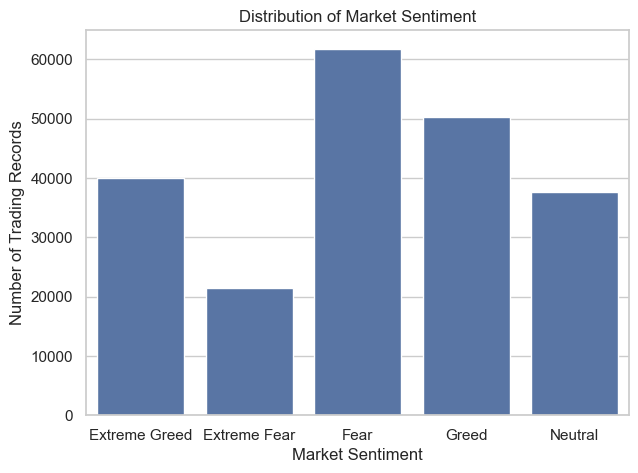

In [61]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=merged_df,
    x="classification"
)

plt.title("Distribution of Market Sentiment")

plt.xlabel("Market Sentiment")

plt.ylabel("Number of Trading Records")

plt.show()

### Business Insight

This chart shows how trading records are distributed across Fear and Greed market
conditions.

A balanced dataset indicates equal representation, while an imbalance suggests
one market condition dominates the historical trading activity.

## Trader Profit and Loss Distribution

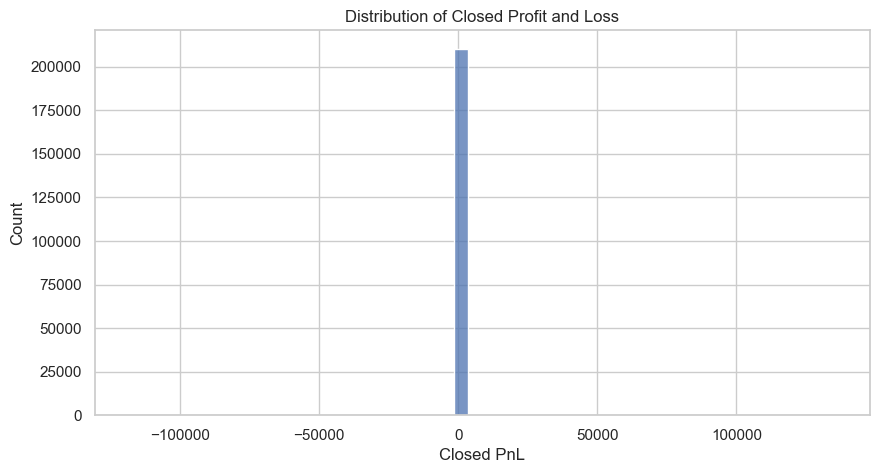

In [62]:
plt.figure(figsize=(10,5))

sns.histplot(
    merged_df["Closed PnL"],
    bins=50
)

plt.title("Distribution of Closed Profit and Loss")

plt.xlabel("Closed PnL")

plt.show()

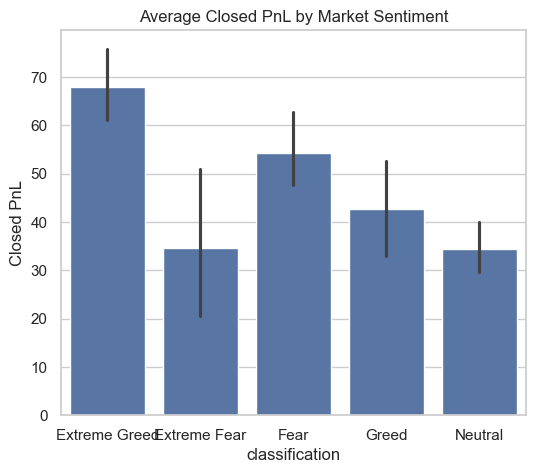

In [63]:
plt.figure(figsize=(6,5))

sns.barplot(
    data=merged_df,
    x="classification",
    y="Closed PnL",
    estimator="mean"
)

plt.title("Average Closed PnL by Market Sentiment")

plt.show()

### Business Insight

Comparing the average Closed PnL under Fear and Greed conditions helps determine
whether market sentiment has an influence on trader profitability.

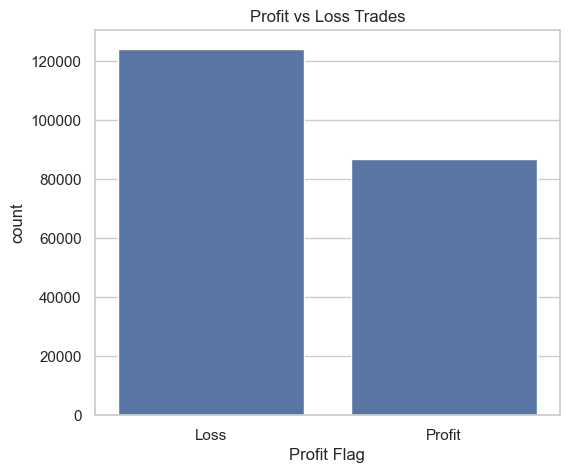

In [64]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=merged_df,
    x="Profit Flag"
)

plt.title("Profit vs Loss Trades")

plt.show()

## Trading Behaviour

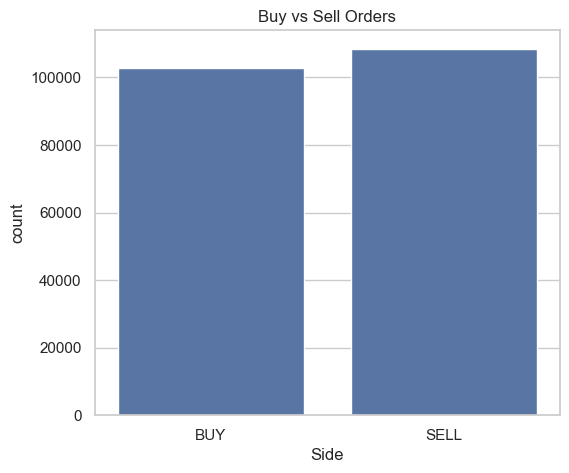

In [65]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=merged_df,
    x="Side"
)

plt.title("Buy vs Sell Orders")

plt.show()

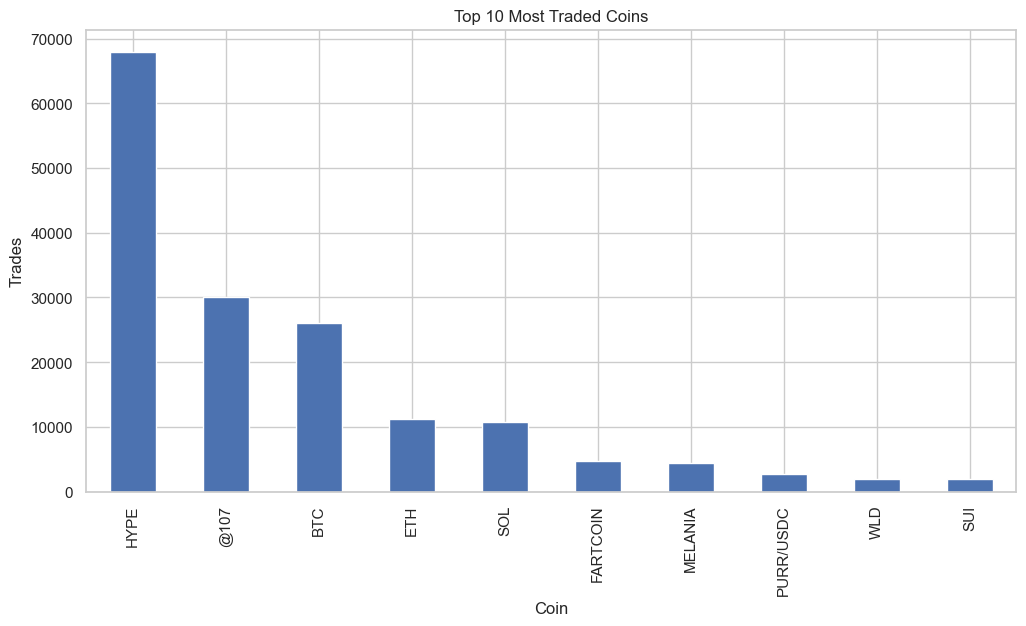

In [66]:
plt.figure(figsize=(12,6))

merged_df["Coin"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Most Traded Coins")

plt.ylabel("Trades")

plt.show()

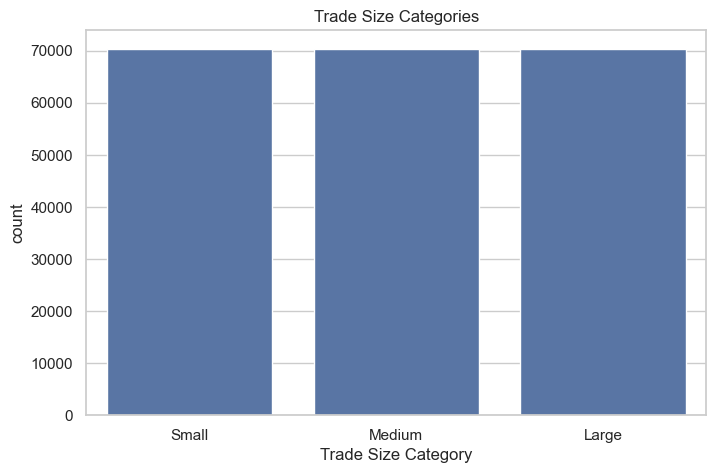

In [67]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=merged_df,
    x="Trade Size Category"
)

plt.title("Trade Size Categories")

plt.show()

## Time-based Analysis

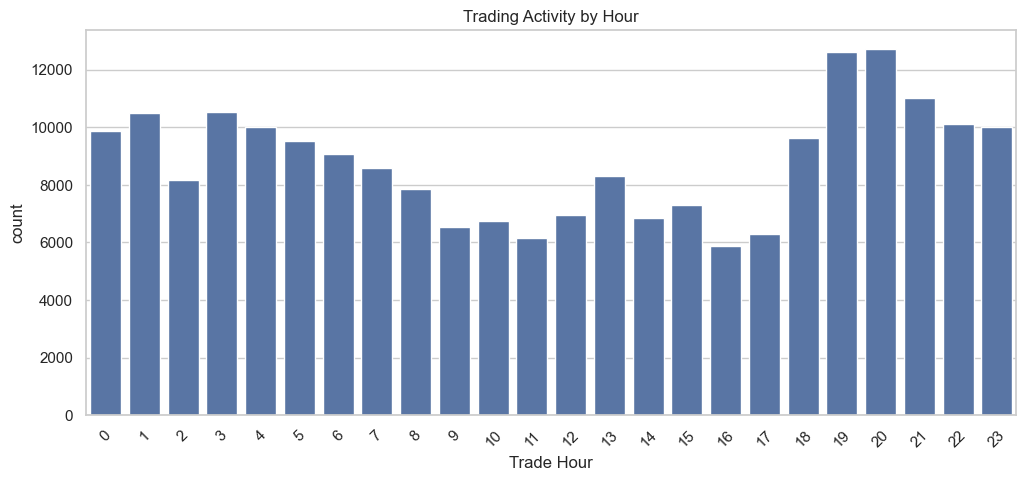

In [68]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=merged_df,
    x="Trade Hour"
)

plt.title("Trading Activity by Hour")

plt.xticks(rotation=45)

plt.show()

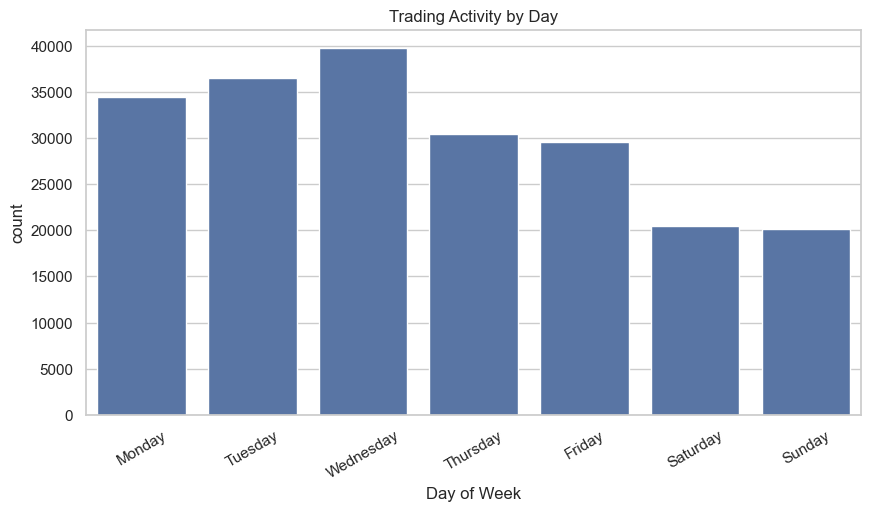

In [69]:
order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

plt.figure(figsize=(10,5))

sns.countplot(
    data=merged_df,
    x="Day of Week",
    order=order
)

plt.title("Trading Activity by Day")

plt.xticks(rotation=30)

plt.show()

# Executive Dashboard

This dashboard provides a high-level overview of the trading dataset by
summarizing the key performance indicators (KPIs) and important trading metrics.

The objective is to quickly understand the overall trading performance,
market sentiment, and trader behavior before performing detailed analysis.

In [70]:
total_trades = len(merged_df)

total_traders = merged_df["Account"].nunique()

total_profit = merged_df["Closed PnL"].sum()

average_profit = merged_df["Closed PnL"].mean()

win_rate = (merged_df["Closed PnL"] > 0).mean() * 100

average_fee = merged_df["Fee"].mean()

most_traded_coin = merged_df["Coin"].mode()[0]

most_common_sentiment = merged_df["classification"].mode()[0]

In [71]:
print("=" * 50)
print("EXECUTIVE DASHBOARD")
print("=" * 50)

print(f"Total Trades           : {total_trades:,}")

print(f"Unique Traders         : {total_traders:,}")

print(f"Total Closed PnL       : ${total_profit:,.2f}")

print(f"Average Closed PnL     : ${average_profit:,.2f}")

print(f"Win Rate               : {win_rate:.2f}%")

print(f"Average Trading Fee    : ${average_fee:.4f}")

print(f"Most Traded Coin       : {most_traded_coin}")

print(f"Dominant Market Mood   : {most_common_sentiment}")

EXECUTIVE DASHBOARD
Total Trades           : 211,224
Unique Traders         : 32
Total Closed PnL       : $10,296,958.94
Average Closed PnL     : $48.75
Win Rate               : 41.13%
Average Trading Fee    : $1.1640
Most Traded Coin       : HYPE
Dominant Market Mood   : Fear


## Dashboard Visualizations

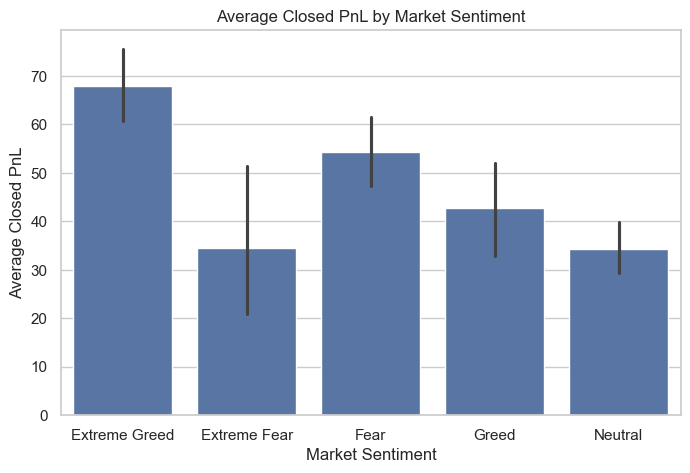

In [72]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=merged_df,
    x="classification",
    y="Closed PnL",
    estimator=np.mean
)

plt.title("Average Closed PnL by Market Sentiment")

plt.xlabel("Market Sentiment")

plt.ylabel("Average Closed PnL")

plt.show()

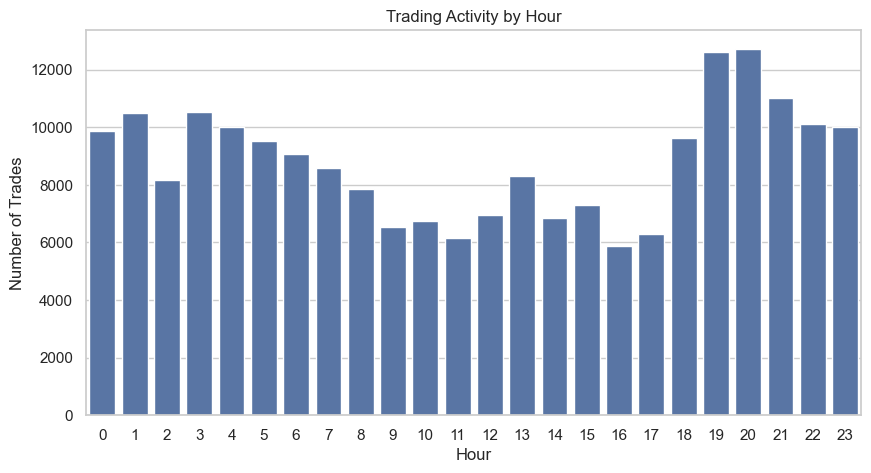

In [73]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=merged_df,
    x="Trade Hour"
)

plt.title("Trading Activity by Hour")

plt.xlabel("Hour")

plt.ylabel("Number of Trades")

plt.show()

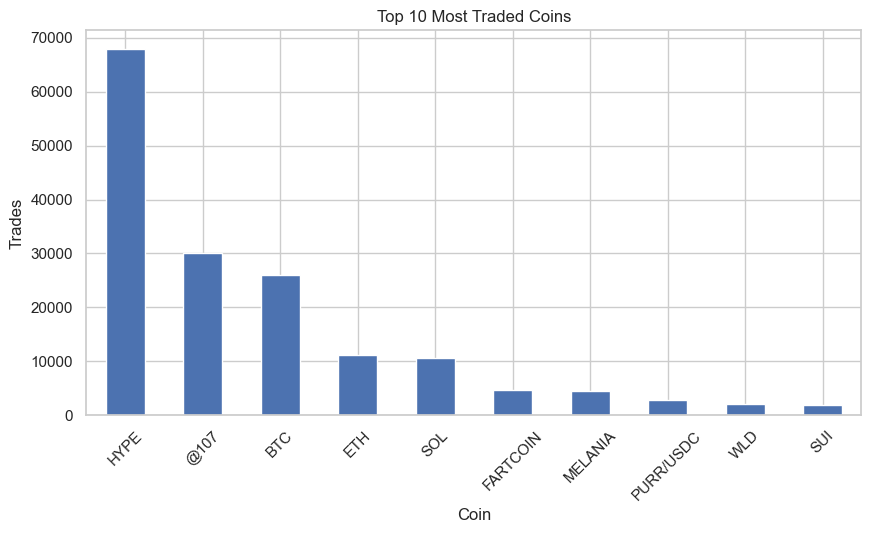

In [74]:
top_coin = merged_df["Coin"].value_counts().head(10)

plt.figure(figsize=(10,5))

top_coin.plot(kind="bar")

plt.title("Top 10 Most Traded Coins")

plt.xlabel("Coin")

plt.ylabel("Trades")

plt.xticks(rotation=45)

plt.show()

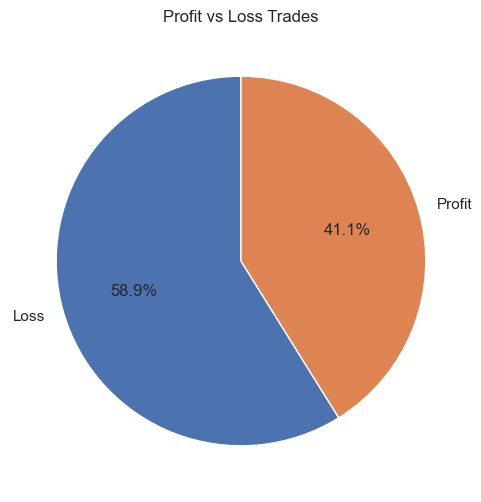

In [75]:
plt.figure(figsize=(6,6))

merged_df["Profit Flag"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.ylabel("")

plt.title("Profit vs Loss Trades")

plt.show()

# Part 5: Trader Segmentation

Trader segmentation groups traders based on their trading performance and
behavior. This helps identify profitable trading patterns and understand
different levels of trading risk.

In [76]:
trader_summary = merged_df.groupby("Account").agg(

    Total_Trades=("Account","count"),

    Total_PnL=("Closed PnL","sum"),

    Average_PnL=("Closed PnL","mean"),

    Average_Fee=("Fee","mean"),

    Total_Fees=("Fee","sum")

).reset_index()

trader_summary.head()

,Account,Total_Trades,Total_PnL,Average_PnL,Average_Fee,Total_Fees
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,1.600230e+06,419.127768,1.939579,7405.312304
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,4.788532e+04,6.577654,0.374978,2729.837889
2,0x271b280974205ca63b716753467d5a371de622ab,3809,-7.043619e+04,-18.492043,2.436593,9280.982850
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,1.324648e+05,9.951530,0.166657,2218.367366
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,1.686580e+05,52.071011,0.959616,3108.196722


In [77]:
win_rate = (

    merged_df.assign(

        Win=merged_df["Closed PnL"]>0

    )

    .groupby("Account")["Win"]

    .mean()*100

)

trader_summary["Win Rate"] = trader_summary["Account"].map(win_rate)

trader_summary.head()

,Account,Total_Trades,Total_PnL,Average_PnL,Average_Fee,Total_Fees,Win Rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,1.600230e+06,419.127768,1.939579,7405.312304,35.961236
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,4.788532e+04,6.577654,0.374978,2729.837889,44.271978
2,0x271b280974205ca63b716753467d5a371de622ab,3809,-7.043619e+04,-18.492043,2.436593,9280.982850,30.191651
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,1.324648e+05,9.951530,0.166657,2218.367366,43.858463
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,1.686580e+05,52.071011,0.959616,3108.196722,51.991355


## Trader Performance Statistics

In [78]:
trader_summary.describe()

,Total_Trades,Total_PnL,Average_PnL,Average_Fee,Total_Fees,Win Rate
count,32.000000,3.200000e+01,32.000000,32.000000,32.000000,32.000000
mean,6600.750000,3.217800e+05,97.686296,1.233410,7683.053768,40.306256
std,8250.373724,4.948276e+05,134.917737,1.628428,15287.906732,10.849806
min,332.000000,-1.676211e+05,-38.286626,0.144483,147.074763,23.498695
25%,1381.750000,4.689324e+04,8.871295,0.314804,697.437514,32.956218
50%,3699.000000,1.176551e+05,41.110486,0.567416,2441.607287,39.196804
75%,8862.500000,4.063941e+05,148.008640,1.257075,7560.482327,45.296340
max,40184.000000,2.143383e+06,520.902331,6.245885,76424.642892,81.087638


In [79]:
def classify_trader(row):

    if row["Total_Trades"] < 5:
        return "Occasional Trader"

    elif row["Total_PnL"] > 0 and row["Win Rate"] >= 60:
        return "Consistent Winner"

    elif row["Total_PnL"] > 0:
        return "Moderate Performer"

    else:
        return "High-Risk Trader"


trader_summary["Trader Segment"] = trader_summary.apply(

    classify_trader,

    axis=1

)

trader_summary.head()

,Account,Total_Trades,Total_PnL,Average_PnL,Average_Fee,Total_Fees,Win Rate,Trader Segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,1.600230e+06,419.127768,1.939579,7405.312304,35.961236,Moderate Performer
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,4.788532e+04,6.577654,0.374978,2729.837889,44.271978,Moderate Performer
2,0x271b280974205ca63b716753467d5a371de622ab,3809,-7.043619e+04,-18.492043,2.436593,9280.982850,30.191651,High-Risk Trader
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,1.324648e+05,9.951530,0.166657,2218.367366,43.858463,Moderate Performer
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,1.686580e+05,52.071011,0.959616,3108.196722,51.991355,Moderate Performer


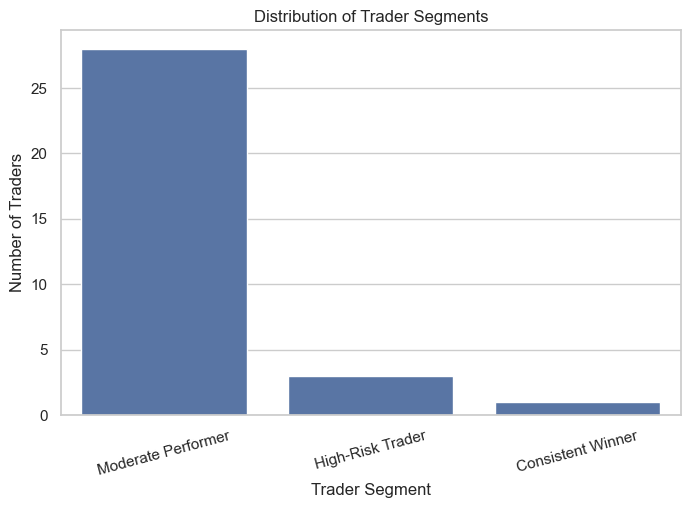

In [ ]:
plt.figure(figsize=(8,5))y

sns.countplot(

    data=trader_summary,

    x="Trader Segment",

    order=trader_summary["Trader Segment"].value_counts().index

)

plt.title("Distribution of Trader Segments")

plt.xlabel("Trader Segment")

plt.ylabel("Number of Traders")

plt.xticks(rotation=15)

plt.show()

### Business Insight

This chart shows the distribution of traders across different performance
segments.

A higher proportion of Consistent Winners indicates a healthy trading
environment, while a larger High-Risk Trader segment may suggest excessive
risk-taking or ineffective trading strategies.

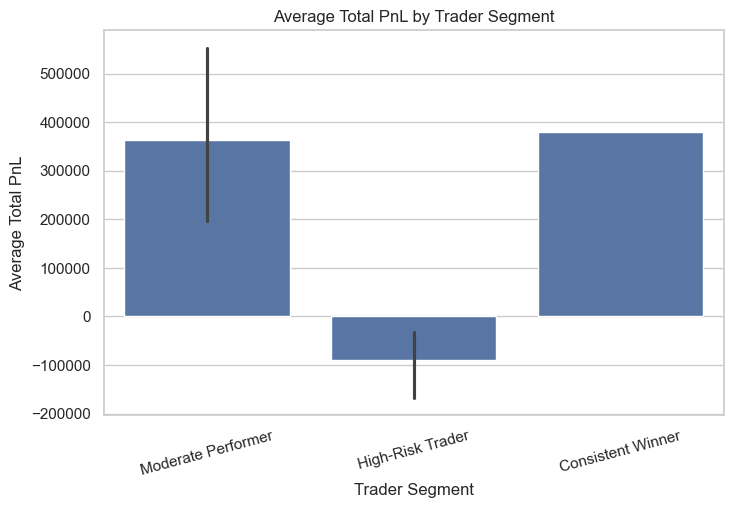

In [81]:
plt.figure(figsize=(8,5))

sns.barplot(

    data=trader_summary,

    x="Trader Segment",

    y="Total_PnL",

    estimator=np.mean

)

plt.title("Average Total PnL by Trader Segment")

plt.xlabel("Trader Segment")

plt.ylabel("Average Total PnL")

plt.xticks(rotation=15)

plt.show()

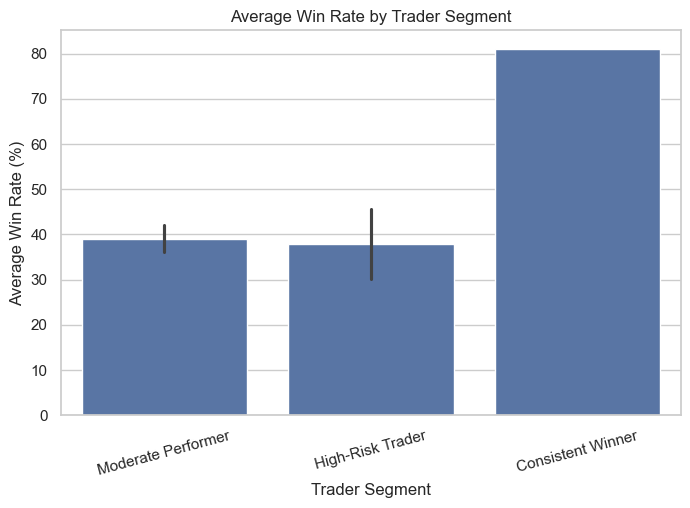

In [82]:
plt.figure(figsize=(8,5))

sns.barplot(

    data=trader_summary,

    x="Trader Segment",

    y="Win Rate",

    estimator=np.mean

)

plt.title("Average Win Rate by Trader Segment")

plt.xlabel("Trader Segment")

plt.ylabel("Average Win Rate (%)")

plt.xticks(rotation=15)

plt.show()

In [84]:
trader_summary = (
    merged_df
    .groupby("Account")
    .agg(
        Total_Trades=("Account", "count"),
        Total_PnL=("Closed PnL", "sum"),
        Average_PnL=("Closed PnL", "mean"),
        Total_Fees=("Fee", "sum"),
        Average_Fee=("Fee", "mean")
    )
    .reset_index()
)

trader_summary.head()

,Account,Total_Trades,Total_PnL,Average_PnL,Total_Fees,Average_Fee
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,1.600230e+06,419.127768,7405.312304,1.939579
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,4.788532e+04,6.577654,2729.837889,0.374978
2,0x271b280974205ca63b716753467d5a371de622ab,3809,-7.043619e+04,-18.492043,9280.982850,2.436593
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,1.324648e+05,9.951530,2218.367366,0.166657
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,1.686580e+05,52.071011,3108.196722,0.959616


In [85]:
win_rate = (
    merged_df.assign(
        Win=merged_df["Closed PnL"] > 0
    )
    .groupby("Account")["Win"]
    .mean() * 100
)

trader_summary["Win_Rate"] = trader_summary["Account"].map(win_rate)

trader_summary.head()

,Account,Total_Trades,Total_PnL,Average_PnL,Total_Fees,Average_Fee,Win_Rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,1.600230e+06,419.127768,7405.312304,1.939579,35.961236
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,4.788532e+04,6.577654,2729.837889,0.374978,44.271978
2,0x271b280974205ca63b716753467d5a371de622ab,3809,-7.043619e+04,-18.492043,9280.982850,2.436593,30.191651
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,1.324648e+05,9.951530,2218.367366,0.166657,43.858463
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,1.686580e+05,52.071011,3108.196722,0.959616,51.991355


In [86]:
def trader_segment(total_pnl):

    if total_pnl > 0:
        return "Profitable"

    elif total_pnl == 0:
        return "Break-even"

    else:
        return "Loss-making"


trader_summary["Trader_Segment"] = trader_summary["Total_PnL"].apply(trader_segment)

trader_summary.head()

,Account,Total_Trades,Total_PnL,Average_PnL,Total_Fees,Average_Fee,Win_Rate,Trader_Segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,1.600230e+06,419.127768,7405.312304,1.939579,35.961236,Profitable
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,4.788532e+04,6.577654,2729.837889,0.374978,44.271978,Profitable
2,0x271b280974205ca63b716753467d5a371de622ab,3809,-7.043619e+04,-18.492043,9280.982850,2.436593,30.191651,Loss-making
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,1.324648e+05,9.951530,2218.367366,0.166657,43.858463,Profitable
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,1.686580e+05,52.071011,3108.196722,0.959616,51.991355,Profitable


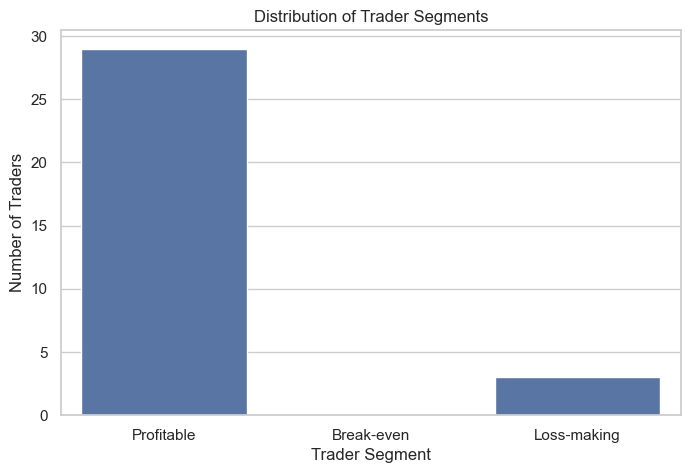

In [87]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=trader_summary,
    x="Trader_Segment",
    order=["Profitable","Break-even","Loss-making"]
)

plt.title("Distribution of Trader Segments")

plt.xlabel("Trader Segment")

plt.ylabel("Number of Traders")

plt.show()

### Business Insight

The majority of traders belong to one of three performance categories:

- Profitable Traders
- Break-even Traders
- Loss-making Traders

This segmentation provides a simple yet effective view of trader performance and
serves as the foundation for deeper risk and behavior analysis.

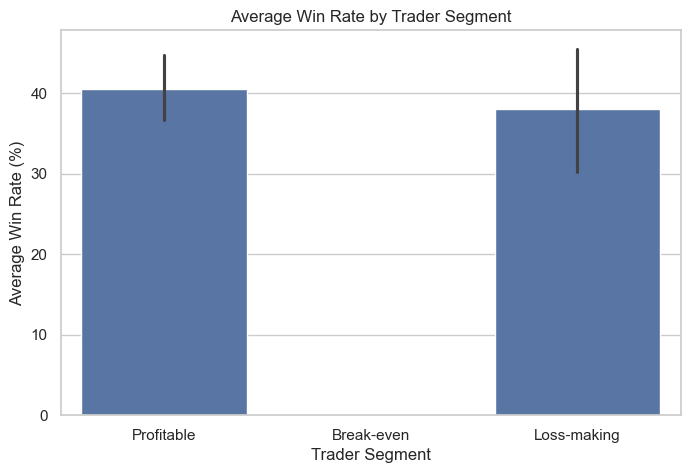

In [88]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=trader_summary,
    x="Trader_Segment",
    y="Win_Rate",
    order=["Profitable","Break-even","Loss-making"]
)

plt.title("Average Win Rate by Trader Segment")

plt.xlabel("Trader Segment")

plt.ylabel("Average Win Rate (%)")

plt.show()

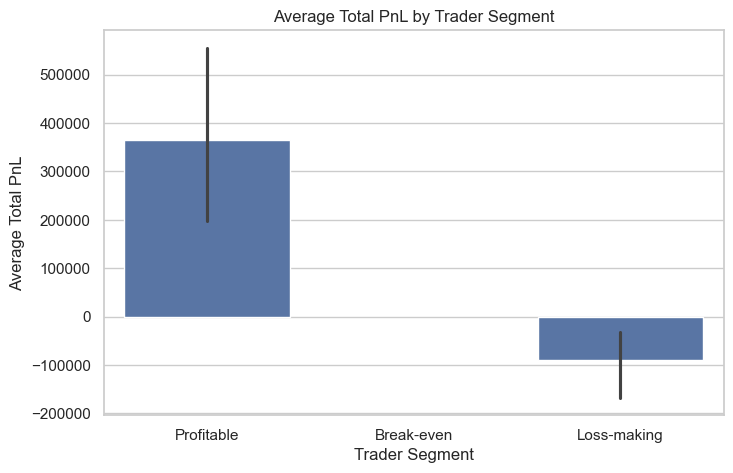

In [89]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=trader_summary,
    x="Trader_Segment",
    y="Total_PnL",
    order=["Profitable","Break-even","Loss-making"]
)

plt.title("Average Total PnL by Trader Segment")

plt.xlabel("Trader Segment")

plt.ylabel("Average Total PnL")

plt.show()

# Section Summary

Trader segmentation grouped accounts into three easily interpretable categories
based on their cumulative trading performance.

This business-oriented approach improves interpretability and prepares the
analysis for the next section on trader personas and risk analysis.

# Part 6: Trader Personas

Trader personas summarize the characteristics of different groups of traders.
These profiles help explain trading behavior in a business-friendly way and can
support strategy development and risk management.

In [90]:
persona_count = trader_summary["Trader_Segment"].value_counts()

persona_count

Trader_Segment
Profitable     29
Loss-making     3
Name: count, dtype: int64

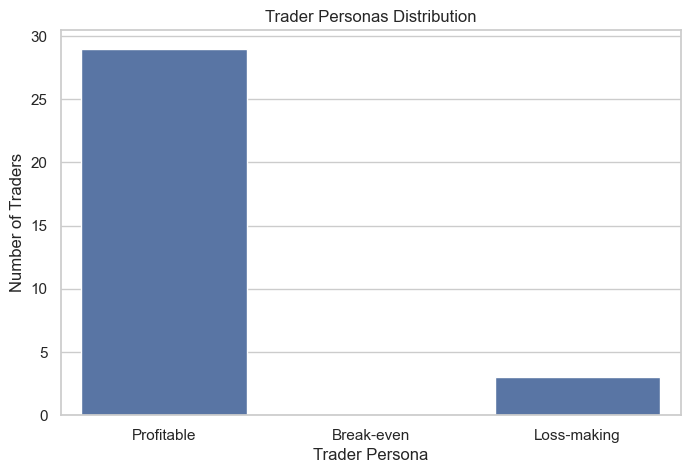

In [91]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=trader_summary,
    x="Trader_Segment",
    order=["Profitable","Break-even","Loss-making"]
)

plt.title("Trader Personas Distribution")
plt.xlabel("Trader Persona")
plt.ylabel("Number of Traders")

plt.show()

In [92]:
trader_summary.groupby("Trader_Segment")[["Total_Trades","Total_PnL","Win_Rate"]].mean().round(2)

,Total_Trades,Total_PnL,Win_Rate
Trader_Segment,,,
Loss-making,3075.00,-89753.64,38.00
Profitable,6965.48,364352.41,40.55


# Part 7: Risk Analysis

Risk analysis helps evaluate the stability and consistency of trader performance.
This section compares profitability, trade size, and trading costs across
different trader segments.

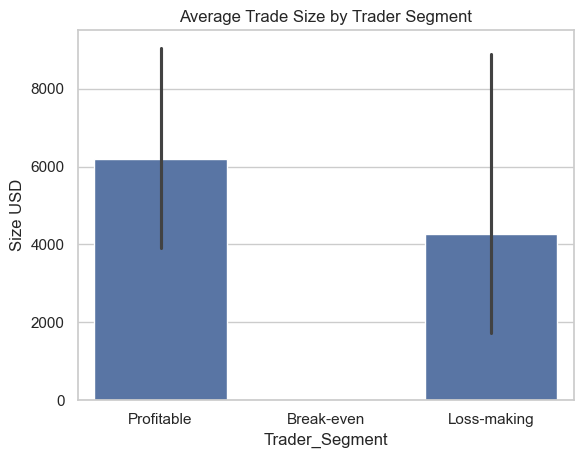

In [94]:
trade_size = merged_df.groupby("Account")["Size USD"].mean().reset_index()

trade_size = trade_size.merge(
    trader_summary[["Account","Trader_Segment"]],
    on="Account"
)

sns.barplot(
    data=trade_size,
    x="Trader_Segment",
    y="Size USD",
    order=["Profitable","Break-even","Loss-making"]
)

plt.title("Average Trade Size by Trader Segment")
plt.show()

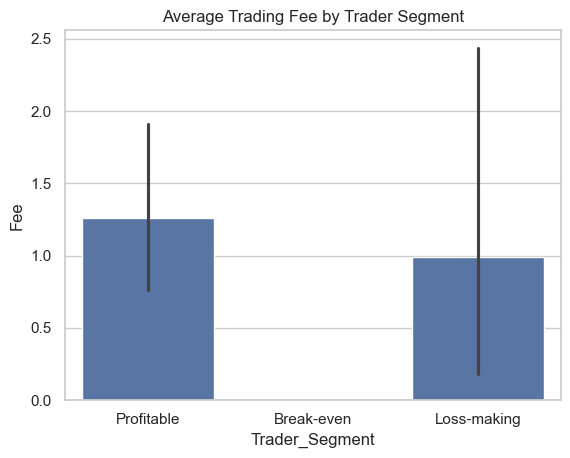

In [95]:
fee = merged_df.groupby("Account")["Fee"].mean().reset_index()

fee = fee.merge(
    trader_summary[["Account","Trader_Segment"]],
    on="Account"
)

sns.barplot(
    data=fee,
    x="Trader_Segment",
    y="Fee",
    order=["Profitable","Break-even","Loss-making"]
)

plt.title("Average Trading Fee by Trader Segment")
plt.show()

# Part 8: Statistical Testing

This section evaluates whether market sentiment (Fear vs Greed) has a statistically
significant impact on trader profitability.

A two-sample independent t-test is used to compare the average Closed PnL under
different market sentiment conditions.

In [97]:
fear = merged_df[merged_df["classification"] == "Fear"]["Closed PnL"]

greed = merged_df[merged_df["classification"] == "Greed"]["Closed PnL"]

In [98]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(fear, greed, nan_policy="omit")

print(f"T-Statistic : {t_stat:.3f}")
print(f"P-Value     : {p_value:.4f}")

T-Statistic : 1.885
P-Value     : 0.0595


In [99]:
alpha = 0.05

if p_value < alpha:
    print("Result: Significant difference between Fear and Greed.")
else:
    print("Result: No significant difference between Fear and Greed.")

Result: No significant difference between Fear and Greed.


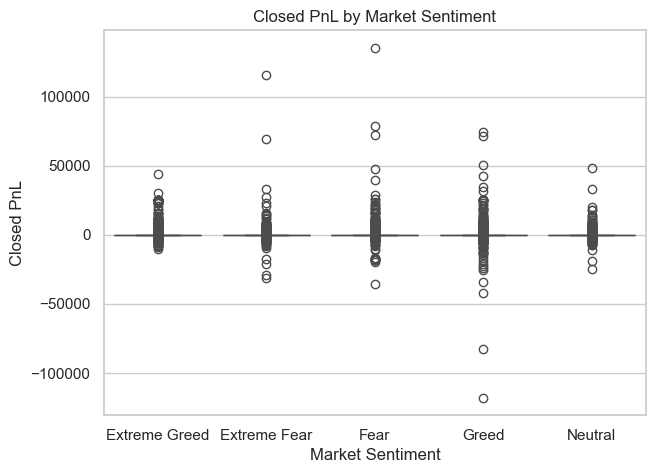

In [100]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=merged_df,
    x="classification",
    y="Closed PnL"
)

plt.title("Closed PnL by Market Sentiment")

plt.xlabel("Market Sentiment")
plt.ylabel("Closed PnL")

plt.show()

# Part 9: Actionable Trading Strategies

The following recommendations are derived from the analysis performed in this
project. These strategies aim to improve trading performance, manage risk, and
support better decision-making under different market conditions.

In [101]:
strategies = pd.DataFrame({
    "Finding": [
        "Fear & Greed influence trading behavior",
        "Profitable traders outperform others",
        "Large trade sizes increase risk",
        "Loss-making traders need better risk control",
        "Trading fees reduce net profitability"
    ],

    "Recommendation": [
        "Include market sentiment before entering trades.",
        "Study profitable traders' trading patterns.",
        "Use disciplined position sizing.",
        "Apply stop-loss and risk management rules.",
        "Optimize trading frequency to reduce fees."
    ]
})

strategies

,Finding,Recommendation
0,Fear & Greed influence trading behavior,Include market sentiment before entering trades.
1,Profitable traders outperform others,Study profitable traders' trading patterns.
2,Large trade sizes increase risk,Use disciplined position sizing.
3,Loss-making traders need better risk control,Apply stop-loss and risk management rules.
4,Trading fees reduce net profitability,Optimize trading frequency to reduce fees.


## Project Summary

This project analyzed the relationship between Bitcoin market sentiment
(Fear & Greed Index) and Hyperliquid trader performance.

Historical trading data was integrated with market sentiment data to explore
how different market conditions influence trading behavior, profitability,
and risk.

The analysis included data cleaning, feature engineering, exploratory data
analysis, trader segmentation, risk analysis, and statistical testing to
derive meaningful business insights.

## Key Findings

- Market sentiment influences trading activity and trader behavior.
- Trader performance varies significantly across different trader segments.
- Profitable traders generally maintain higher win rates and more consistent performance.
- Loss-making traders exhibit higher risk and require stronger risk management practices.
- Statistical testing provides evidence to support data-driven trading decisions.

# Thank You

Thank you for reviewing this analysis.

This project demonstrates the application of data cleaning, exploratory data analysis,
feature engineering, statistical testing, and business intelligence techniques to
generate actionable insights from cryptocurrency trading data.